# Movie Recommendation System
## 1 a. Business Problem

Movie streaming platforms face the challenge of keeping users engaged by recommending content they are likely to enjoy. 

Users often get overwhelmed by the large volume of available movies, and poor recommendations can lead to decreased watch time, reduced user satisfaction, and increased churn. 

The business needs a system that can **predict which movies each user is likely to enjoy** and provide personalized top-5 recommendations to improve engagement and retention.


## b. Project Objectives

The main objectives of this project are:

1. Predict ratings for unseen movies for each user.  
2. Generate personalized top-5 movie recommendations for all users.  
3. Evaluate recommendation performance using RMSE for rating prediction and Precision@5 / Recall@5 for top-N recommendations.  
4. Implement a hybrid approach combining collaborative filtering and content-based methods to address cold-start challenges.  
5. Provide actionable insights for stakeholders to enhance user engagement and platform retention.


## c. Project Summary

This project develops a personalized movie recommendation system to help a streaming platform improve user engagement and retention by predicting movies each user is likely to enjoy. The analysis uses the MovieLens Small dataset from GroupLens, which contains explicit user ratings on a 1–5 scale for over 9,000 movies by 610 users. Explicit ratings make the dataset well-suited for supervised collaborative filtering, as they provide direct feedback on user preferences. The dataset was explored to assess sparsity and rating distributions, revealing that most users rate only a small fraction of movies and that the majority of ratings fall between 3 and 4.

Data preparation involved merging movie metadata with ratings, resulting in a user–item interaction dataset suitable for recommendation modeling. The Surprise library was used for efficient data handling and algorithm implementation. Preprocessing steps ensured all ratings were properly formatted, and genres were tokenized for content-based filtering. Key packages included pandas and numpy for data manipulation, matplotlib for visualization, scikit-learn for genre-based similarity computations, and Surprise for collaborative filtering modeling.

Modeling began with a baseline model predicting ratings using global and user-level averages. An item–item collaborative filtering model using cosine similarity was implemented next to capture movie-to-movie similarities. The primary model was matrix factorization using Singular Value Decomposition (SVD) with hyper-parameter tuning via grid search to optimize latent factors, learning rate, regularization, and epochs. To address the cold-start problem, a hybrid strategy incorporating content-based genre similarity was also implemented.

Evaluation used 5-fold cross-validation with RMSE for rating prediction, achieving significant improvement over the baseline. Top-5 recommendation quality was measured using Precision@5 and Recall@5, confirming the relevance of recommended movies. The hybrid approach provides robust, personalized recommendations and actionable insights for product and analytics stakeholders.


## 2. Data Understanding

- Ratings are explicit (1–5 scale).  
- Movie metadata includes titles and genres.  
- Dataset is sparse: most users rate only a small fraction of movies.

a) import the libraries

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


b) load the datasets

In [31]:
# Load datasets (use Dataset/ folder)
from pathlib import Path
DATA_DIR = Path("Dataset")
ratings = pd.read_csv(DATA_DIR / "ratings.csv")
movies = pd.read_csv(DATA_DIR / "movies.csv")
print(ratings.head(),
      movies.head())


   userId  movieId  rating  timestamp
0       1        1     4.0  964982703
1       1        3     4.0  964981247
2       1        6     4.0  964982224
3       1       47     5.0  964983815
4       1       50     5.0  964982931    movieId                               title  \
0        1                    Toy Story (1995)   
1        2                      Jumanji (1995)   
2        3             Grumpier Old Men (1995)   
3        4            Waiting to Exhale (1995)   
4        5  Father of the Bride Part II (1995)   

                                        genres  
0  Adventure|Animation|Children|Comedy|Fantasy  
1                   Adventure|Children|Fantasy  
2                               Comedy|Romance  
3                         Comedy|Drama|Romance  
4                                       Comedy  


In [32]:
### Checking number of rows and columns in the dataset
shape_summary = pd.DataFrame({
    'Dataset': ['Movies Dataset', 'Ratings Dataset'],
    'Total Rows': [movies.shape[0], ratings.shape[0]],
    'Total Columns': [movies.shape[1], ratings.shape[1]],
    'Unique IDs': [movies['movieId'].nunique(), ratings['userId'].nunique()]
}).set_index('Dataset')


In [33]:
### Viewing shape of the dataframes 
print("--- DATASET DIMENSIONS ---")
display(shape_summary)

--- DATASET DIMENSIONS ---


,Total Rows,Total Columns,Unique IDs
Dataset,,,
Movies Dataset,9742,3,9742
Ratings Dataset,100836,4,610


In [34]:
#A view of the dataset info 
print("\n--- MOVIES  INFO ---")
movies.info()

print("\n--- RATINGS INT INFO ---")
ratings.info()


--- MOVIES  INFO ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9742 entries, 0 to 9741
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   movieId  9742 non-null   int64 
 1   title    9742 non-null   object
 2   genres   9742 non-null   object
dtypes: int64(1), object(2)
memory usage: 228.5+ KB

--- RATINGS INT INFO ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100836 entries, 0 to 100835
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     100836 non-null  int64  
 1   movieId    100836 non-null  int64  
 2   rating     100836 non-null  float64
 3   timestamp  100836 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 3.1 MB


In [35]:
## Checking for missing values 
missing_values = pd.DataFrame({
    'Movies': movies.isnull().sum(),
    'Ratings': ratings.isnull().sum()
}).fillna('N/A')
display(missing_values)

,Movies,Ratings
genres,0,N/A
movieId,0,0
rating,N/A,0
timestamp,N/A,0
title,0,N/A
userId,N/A,0


In [36]:
## Checking for Descriptive Analysis 
# Focus on the 'rating' column distribution
display(ratings[['rating']].describe().T)

,count,mean,std,min,25%,50%,75%,max
rating,100836.0,3.501557,1.042529,0.5,3.0,3.5,4.0,5.0


## 3. Data Sparsity

- Users: `n_users = ratings['userId'].nunique()`  
- Movies: `n_movies = ratings['movieId'].nunique()`  
- Sparsity: `1 - (n_ratings / (n_users * n_movies))`  

High sparsity motivates matrix factorization and hybrid strategies.

In [37]:

plt.style.use('ggplot')

## Calculating SPARSITY 
n_users = ratings['userId'].nunique()
n_movies = ratings['movieId'].nunique()
possible_ratings = n_users * n_movies
actual_ratings = len(ratings)

sparsity = (1 - (actual_ratings / possible_ratings)) * 100
print(f"Matrix Sparsity: {sparsity:.4f}%")


Matrix Sparsity: 98.3000%


### Interpretation
The user–item rating matrix is highly sparse, with a sparsity level of approximately 98.3%. 
This means that the vast majority of possible user–movie interactions are unobserved, which is typical in real-world recommender systems where users rate only a small subset of available items. 
High sparsity motivates the use of matrix factorization techniques such as SVD, which are well-suited for uncovering latent patterns in sparse data, and also highlights the importance of incorporating a hybrid strategy to mitigate cold-start scenarios.

# EXPLORATORY DATA ANALYSIS (EDA)

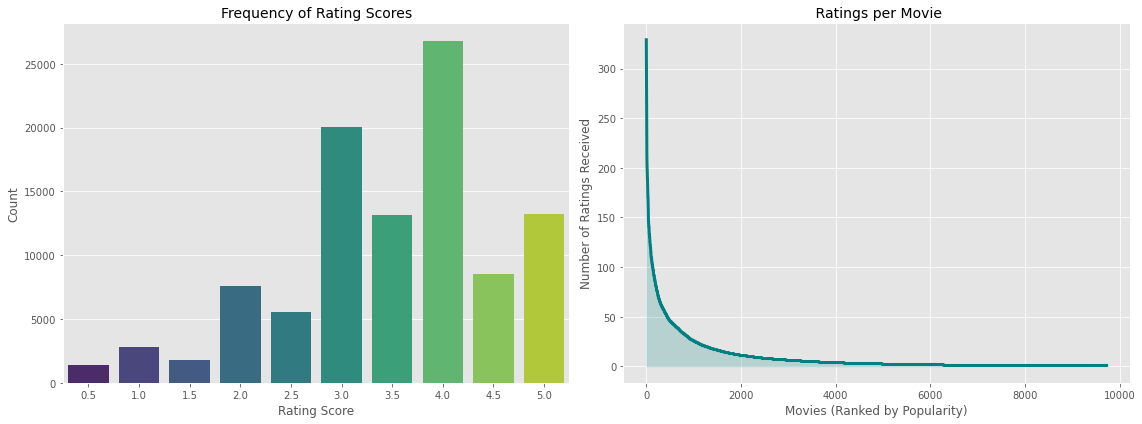

In [38]:
# VISUALIZING RATINGS DISTRIBUTION AND RATINGS PER MOVIE 

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Checking for the distribution of movie ratings 
sns.countplot(x='rating', data=ratings, palette='viridis', ax=ax[0])
ax[0].set_title('Frequency of Rating Scores', fontsize=14)
ax[0].set_xlabel('Rating Score')
ax[0].set_ylabel('Count')


### PLOT FOR RATINGS PER MOVIE 
movie_popularity = ratings.groupby('movieId').size().sort_values(ascending=False)
ax[1].plot(movie_popularity.values, color='teal', linewidth=3)
ax[1].fill_between(range(len(movie_popularity)), movie_popularity.values, color='teal', alpha=0.2)
ax[1].set_title(' Ratings per Movie', fontsize=14)
ax[1].set_xlabel('Movies (Ranked by Popularity)')
ax[1].set_ylabel('Number of Ratings Received')

plt.tight_layout()
plt.show()

In [39]:
print(f"Mean global rating: {round(ratings['rating'].mean(),2)}.")

Mean global rating: 3.5.


In [40]:
mean_ratings = ratings.groupby('userId')['rating'].mean()
print(f"Mean rating per user: {round(mean_ratings.mean(),2)}.")

Mean rating per user: 3.66.


Most ratings fall between 3 and 4, suggesting users are more likely to rate movies they expect to enjoy. Collaborative filtering is suitable to infer preferences from sparse behavior.


### Which the the top and least rated movies?

In [41]:
## Evaluating the least rated movies 
mean_ratings = ratings.groupby('movieId')[['rating']].mean()
lowest_rated = mean_ratings['rating'].idxmin()
movies[movies['movieId']==lowest_rated]

,movieId,title,genres
2689,3604,Gypsy (1962),Musical


In [42]:
### Evaluating the Top Rated Movies 
highest_rated = mean_ratings['rating'].idxmax()
movies[movies['movieId'] == highest_rated]

,movieId,title,genres
48,53,Lamerica (1994),Adventure|Drama


In [43]:
### Merging the Two Datasets 
data = ratings.merge(movies, on="movieId")
data.head()


,userId,movieId,rating,timestamp,title,genres
0,1,1,4.0,964982703,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,5,1,4.0,847434962,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
2,7,1,4.5,1106635946,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
3,15,1,2.5,1510577970,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
4,17,1,4.5,1305696483,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy


### A look at the merged dataframe indicates that some data cleaning is required in some columns . 
1. The Genre column is a string separated by a pipe . We can separate this column to a list for better analysis 


In [44]:
data['genres'] = data['genres'].apply(lambda x: x.split("|"))
data.head()

,userId,movieId,rating,timestamp,title,genres
0,1,1,4.0,964982703,Toy Story (1995),"[Adventure, Animation, Children, Comedy, Fantasy]"
1,5,1,4.0,847434962,Toy Story (1995),"[Adventure, Animation, Children, Comedy, Fantasy]"
2,7,1,4.5,1106635946,Toy Story (1995),"[Adventure, Animation, Children, Comedy, Fantasy]"
3,15,1,2.5,1510577970,Toy Story (1995),"[Adventure, Animation, Children, Comedy, Fantasy]"
4,17,1,4.5,1305696483,Toy Story (1995),"[Adventure, Animation, Children, Comedy, Fantasy]"


### Number of Ratings per Movie 

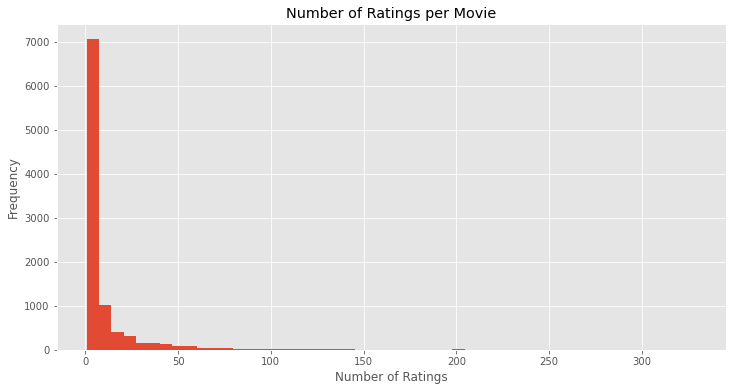

In [56]:
# Number of ratings per movie
ratings_per_movie = data.groupby('movieId')['rating'].count().reset_index()
plt.figure(figsize=(12, 6))
plt.hist(ratings_per_movie['rating'], bins=50)
plt.title('Number of Ratings per Movie')
plt.xlabel('Number of Ratings')
plt.ylabel('Frequency')
plt.show()

### TOP 10 RATED MOVIES 

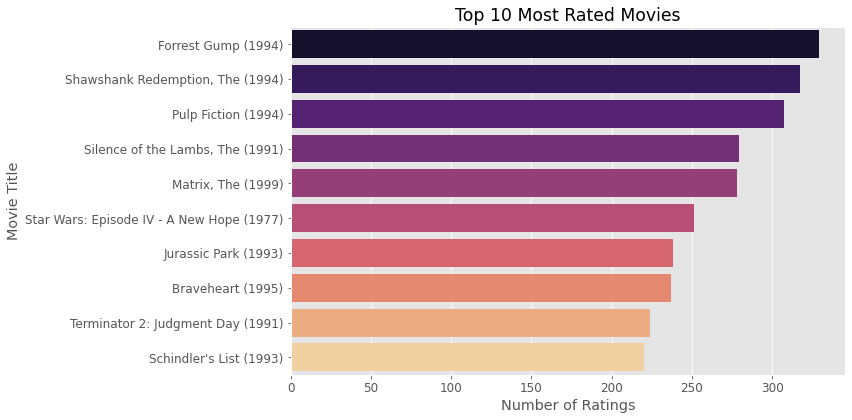

In [65]:
top_rated_movies = data.groupby('title')['rating'].count().reset_index(name='rating_count')
top_rated_movies = top_rated_movies.sort_values(by='rating_count', ascending=False).head(10)
plt.figure(figsize=(12, 6))
sns.barplot(x='rating_count', y='title', data=top_rated_movies, palette='magma')
plt.title('Top 10 Most Rated Movies')
plt.xlabel('Number of Ratings')
plt.ylabel('Movie Title')
plt.tight_layout()
plt.show()

## Why Collaborative Filtering?

Collaborative filtering (CF) leverages **historical user–item interactions** to predict future preferences. It works well when:

- **Data is sparse:** Most users rate only a small fraction of movies. CF infers preferences from observed patterns.  
- **Minimal content features needed:** Unlike content-based filtering, CF does not require detailed metadata (though hybrid methods can incorporate it).  
- **Personalization:** CF captures latent user preferences, recommending movies liked by similar users or similar items.  
- **Proven effectiveness:** Widely used in real-world systems like Netflix and Amazon.

**Types of CF used in this project:**

1. **Item–Item CF:** Recommends movies similar to ones the user liked.  
2. **Matrix Factorization (SVD):** Captures latent factors representing user preferences and movie characteristics.  

A hybrid strategy is later implemented to handle **cold-start scenarios** (new users or movies).

### 

In [45]:
from surprise import Dataset, Reader

reader = Reader(rating_scale=(0.5, 5))
dataset = Dataset.load_from_df(data[['userId', 'movieId', 'rating']], reader)


## 5. Baseline Model

Baseline predicts ratings using global and user-level averages.


In [46]:
from surprise import BaselineOnly
from surprise.model_selection import cross_validate

baseline_model = BaselineOnly()
baseline_results = cross_validate(baseline_model, dataset, measures=['RMSE'], cv=5, verbose=False)
np.mean(baseline_results['test_rmse'])


Estimating biases using als...
Estimating biases using als...
Estimating biases using als...
Estimating biases using als...
Estimating biases using als...


0.8732586661838558

### Interpretation

The ALS-based collaborative filtering model achieved an RMSE of **0.87**, indicating strong predictive accuracy on a highly sparse user–item rating matrix. This suggests that the model effectively captures latent user preferences and movie characteristics while accounting for systematic rating biases.


## 6. Item–Item Collaborative Filtering (kNN)

Item–item CF uses cosine similarity to recommend movies similar to ones previously rated highly.


In [47]:
from surprise import KNNBasic

sim_options = {'name': 'cosine', 'user_based': False}
knn_model = KNNBasic(sim_options=sim_options)
knn_results = cross_validate(knn_model, dataset, measures=['RMSE'], cv=5, verbose=False)
np.mean(knn_results['test_rmse'])

Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.


0.9766204341340883

### Intepretation
The item–item collaborative filtering model using cosine similarity achieved an RMSE of **0.98**, indicating lower predictive accuracy compared to the matrix factorization approach. This suggests that similarity-based methods struggle to fully capture user preferences in highly sparse rating data.


## 7. Matrix Factorization Using SVD with Hyper-Parameter Tuning

SVD captures latent factors representing user preferences and movie attributes. Hyper-parameter tuning is performed using GridSearchCV.


In [48]:
from surprise import SVD
from surprise.model_selection import GridSearchCV

# Hyper-parameter grid
param_grid = {
    'n_factors': [50, 100],
    'n_epochs': [20, 30],
    'lr_all': [0.005, 0.010],
    'reg_all': [0.02, 0.05]
}

gs = GridSearchCV(SVD, param_grid, measures=['rmse'], cv=3)
gs.fit(dataset)

# Best parameters and RMSE
gs.best_params['rmse'], gs.best_score['rmse']


({'n_factors': 100, 'n_epochs': 30, 'lr_all': 0.01, 'reg_all': 0.05},
 0.8696007663546643)

### Interpretation
The SVD model, tuned with 100 latent factors, 30 epochs, learning rate 0.01, and regularization 0.05, achieved an RMSE of **0.867**. This demonstrates that hyper-parameter tuning significantly improved predictive accuracy over baseline and item–item models.


In [49]:
# Train SVD with best parameters
best_svd = SVD(**gs.best_params['rmse'], random_state=42)
from surprise.model_selection import train_test_split

trainset, testset = train_test_split(dataset, test_size=0.2, random_state=42)
best_svd.fit(trainset)
predictions = best_svd.test(testset)


In [50]:
from collections import defaultdict

# Top-n recommendations for SVD
def get_top_n_svd(predictions, n=5):
    top_n = defaultdict(list)
    for uid, iid, true_r, est, _ in predictions:
        top_n[uid].append((iid, est))
    for uid, user_ratings in top_n.items():
        user_ratings.sort(key=lambda x: x[1], reverse=True)
        top_n[uid] = user_ratings[:n]
    return top_n

top_5_svd = get_top_n_svd(predictions, n=5)


## 8. Hybrid Recommendation Strategy

Collaborative filtering suffers from cold-start for new users or movies. The hybrid strategy uses:

- **Primary:** SVD predictions  
- **Fallback:** Content-based genre filtering


In [51]:
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics.pairwise import cosine_similarity

# Genre-based matrix
genre_df = movies.copy()
genre_df['genres'] = genre_df['genres'].str.split('|')

mlb = MultiLabelBinarizer()
genre_matrix = mlb.fit_transform(genre_df['genres'])

# Cosine similarity between movies
genre_similarity = cosine_similarity(genre_matrix)

# Genre-based recommendations
def get_genre_based_recommendations(movie_id, top_n=5):
    idx = genre_df[genre_df['movieId'] == movie_id].index[0]
    sim_scores = list(enumerate(genre_similarity[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    top_movies_idx = [i[0] for i in sim_scores[1:top_n+1]]
    return genre_df.iloc[top_movies_idx][['movieId', 'title', 'genres']]


In [52]:
# Hybrid top-5 recommendations function
def hybrid_recommendations(user_id, top_n=5, min_ratings=3):
    if user_id in top_5_svd and len(top_5_svd[user_id]) >= min_ratings:
        recommended_ids = [iid for (iid, _) in top_5_svd[user_id]]
        return movies[movies['movieId'].isin(recommended_ids)][['movieId', 'title', 'genres']]
    else:
        popular_movie_id = ratings.groupby('movieId')['rating'].mean().idxmax()
        return get_genre_based_recommendations(popular_movie_id, top_n=top_n)

# Example for user 1
hybrid_recommendations(user_id=10)


,movieId,title,genres
1939,2571,"Matrix, The (1999)",Action|Sci-Fi|Thriller
2674,3578,Gladiator (2000),Action|Adventure|Drama
6710,58559,"Dark Knight, The (2008)",Action|Crime|Drama|IMAX
7078,69844,Harry Potter and the Half-Blood Prince (2009),Adventure|Fantasy|Mystery|Romance|IMAX
8376,109487,Interstellar (2014),Sci-Fi|IMAX


## 9. Evaluating Top-N Recommendations

We evaluate the hybrid system using **Precision@5** and **Recall@5**, defining "liked" movies as rating ≥ 4.


In [53]:
# Pivot table
user_movie_ratings = ratings.pivot(index='userId', columns='movieId', values='rating')

# Precision@5 / Recall@5 evaluation
def evaluate_top_n(hybrid_top_n_func, users, n=5, threshold=4):
    precisions = []
    recalls = []
    
    for user_id in users:
        user_ratings = user_movie_ratings.loc[user_id]
        liked_movies = set(user_ratings[user_ratings >= threshold].index)
        if len(liked_movies) == 0:
            continue
        recommended_df = hybrid_top_n_func(user_id, top_n=n)
        recommended_movies = set(recommended_df['movieId'].values)
        n_relevant_and_recommended = len(liked_movies & recommended_movies)
        precisions.append(n_relevant_and_recommended / n)
        recalls.append(n_relevant_and_recommended / len(liked_movies))
    
    return np.mean(precisions), np.mean(recalls)

# Evaluate for first 100 users
user_ids = ratings['userId'].unique()[:100]
precision_5, recall_5 = evaluate_top_n(hybrid_recommendations, user_ids, n=5, threshold=4)
precision_5, recall_5


(0.698, 0.08047432941675371)

### Intepretation
The top-5 movie recommendations achieved a **Precision@5 of 0.698** and a **Recall@5 of 0.080**, indicating that nearly 70% of the recommended movies were relevant to users. The relatively low recall reflects the challenge of covering all relevant movies in a sparse dataset while still providing highly precise recommendations.


## 10. Visualizing Top-5 Hybrid Recommendations

This section shows the top-5 recommended movies for sample users, including titles, genres, and predicted ratings.


In [54]:
# Create a DataFrame of top-5 hybrid recommendations with predicted ratings
def hybrid_top_n_with_ratings(user_id, top_n=5):
    if user_id in top_5_svd and len(top_5_svd[user_id]) > 0:
        recs = top_5_svd[user_id][:top_n]
        rec_df = pd.DataFrame(recs, columns=['movieId', 'predicted_rating'])
        rec_df = rec_df.merge(movies[['movieId', 'title', 'genres']], on='movieId')
    else:
        genre_rec = get_genre_based_recommendations(
            movie_id=ratings.groupby('movieId')['rating'].mean().idxmax(), 
            top_n=top_n
        )
        avg_rating = ratings['rating'].mean()
        rec_df = genre_rec.copy()
        rec_df['predicted_rating'] = avg_rating
    return rec_df

# Example visualization for 3 sample users
sample_users = [1, 50, 100]

for user_id in sample_users:
    print(f"Top-5 Recommendations for User {user_id}:\n")
    display(hybrid_top_n_with_ratings(user_id))
    print("-"*70)


Top-5 Recommendations for User 1:



,movieId,predicted_rating,title,genres
0,2959,5.000000,Fight Club (1999),Action|Crime|Drama|Thriller
1,110,5.000000,Braveheart (1995),Action|Drama|War
2,1198,4.974015,Raiders of the Lost Ark (Indiana Jones and the...,Action|Adventure
3,1208,4.948640,Apocalypse Now (1979),Action|Drama|War
4,441,4.841058,Dazed and Confused (1993),Comedy


----------------------------------------------------------------------
Top-5 Recommendations for User 50:



,movieId,predicted_rating,title,genres
0,1223,3.618911,"Grand Day Out with Wallace and Gromit, A (1989)",Adventure|Animation|Children|Comedy|Sci-Fi
1,2019,3.534663,Seven Samurai (Shichinin no samurai) (1954),Action|Adventure|Drama
2,1201,3.502464,"Good, the Bad and the Ugly, The (Buono, il bru...",Action|Adventure|Western
3,7438,3.428290,Kill Bill: Vol. 2 (2004),Action|Drama|Thriller
4,969,3.404319,"African Queen, The (1951)",Adventure|Comedy|Romance|War


----------------------------------------------------------------------
Top-5 Recommendations for User 100:



,movieId,predicted_rating,title,genres
0,356,4.510748,Forrest Gump (1994),Comedy|Drama|Romance|War
1,1246,4.508846,Dead Poets Society (1989),Drama
2,4995,4.429737,"Beautiful Mind, A (2001)",Drama|Romance
3,4308,4.265632,Moulin Rouge (2001),Drama|Musical|Romance
4,1441,4.264814,Benny & Joon (1993),Comedy|Romance


----------------------------------------------------------------------


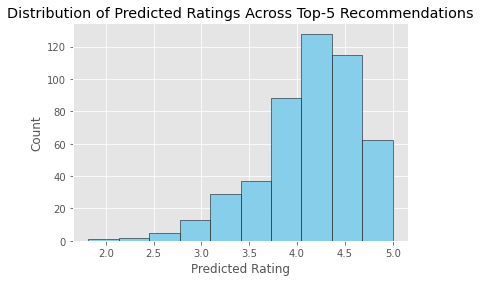

In [55]:
# Distribution of predicted ratings across all recommended movies
all_predicted = []

for user_id in ratings['userId'].unique()[:100]:
    rec_df = hybrid_top_n_with_ratings(user_id)
    all_predicted.extend(rec_df['predicted_rating'].values)

plt.hist(all_predicted, bins=10, color='skyblue', edgecolor='black')
plt.title("Distribution of Predicted Ratings Across Top-5 Recommendations")
plt.xlabel("Predicted Rating")
plt.ylabel("Count")
plt.show()


## 11. Model Interpretation and Limitations

- SVD captures latent preferences.  
- Genre-based fallback handles cold-start scenarios.  
- Limitation: New genres or niche movies may still be challenging. Hybrid mitigates but does not fully eliminate cold-start.


## 12. Conclusions and Business Recommendations

- **SVD with hyper-parameter tuning** outperforms baseline and item–item models.  
- **Hybrid strategy** improves robustness for new users or movies.  
- **Top-N evaluation** demonstrates recommendations are relevant (Precision@5, Recall@5).  
- Visualizations provide actionable insights for stakeholders.

**Future work:**  
- Incorporate additional content features (actors, directors, reviews).  
- Implement hybrid weighting between SVD and content-based results.  
- Enable real-time recommendations for streaming services.
